### Entrenamiento del Modelo — Predicción de Enfermedad Cardíaca

Este notebook continúa el análisis exploratorio (`EDA_Predicción_de_Enfermedad_Cardíaca.ipynb`) y cubre el entrenamiento y la evaluación del modelo.

**Alcance de este notebook:** carga de datos → preparación → entrenamiento → evaluación.

**Lo que queda para trabajarse en clase, a propósito:**
- La construcción del *bundle* de despliegue (pipeline + orden de columnas + metadata + versiones)
- La API que consume ese bundle


## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

## 2. Carga de datos


In [2]:
df = pd.read_csv("heart.csv")
df.head()

,sbp,Tabaco,ldl,Adiposidad,Familia,Tipo,Obesidad,Alcohol,Edad,chd
0,160,12.00,5.73,23.11,Presente,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Ausente,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Presente,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Presente,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Presente,60,25.99,57.34,49,1


## 3. Codificación de la variable categórica

`Familia` es la única columna no numérica (`Presente` / `Ausente`). Según la definición del dataset, se codifica directamente como `Presente=1`, `Ausente=0`.

No se requiere imputación de nulos: el EDA ya confirmó que no hay valores faltantes en ninguna columna.

In [3]:
df["Familia"] = df["Familia"].map({"Presente": 1, "Ausente": 0})

assert df["Familia"].isnull().sum() == 0, "Revisar categorías no mapeadas en Familia"
df.head()

,sbp,Tabaco,ldl,Adiposidad,Familia,Tipo,Obesidad,Alcohol,Edad,chd
0,160,12.00,5.73,23.11,1,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,0,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,1,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,1,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,1,60,25.99,57.34,49,1


## 4. Variables predictoras y variable objetivo

`chd` es la variable objetivo (cardiopatía coronaria: sí=1, no=0). El resto de las columnas son predictoras.

In [4]:
X = df.drop(columns="chd")
y = df["chd"]

print("Distribución de la variable objetivo:")
print(y.value_counts(normalize=True).round(3))

Distribución de la variable objetivo:
chd
0    0.654
1    0.346
Name: proportion, dtype: float64


## 5. División train / test

El desbalance de clases es moderado (~35% positivos). Se usa `stratify=y` para conservar esa proporción en ambos conjuntos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (369, 9)  Test: (93, 9)


## 6. Escalado + entrenamiento en un Pipeline

La regresión logística es sensible a la escala de las variables: sin escalar, una columna como `Alcohol` (rango ~0–147) domina sobre una como `Familia` (0/1) en la magnitud de los coeficientes, y la optimización converge peor.

En vez de ajustar el `scaler` por un lado y el modelo por otro, se combinan en un `Pipeline`. Ventajas concretas, no solo estilo:

- **Un solo `.fit()`**: el `scaler` se ajusta con `X_train` y el modelo se entrena con esos datos ya escalados, en un solo paso — no hay forma de ajustar el scaler con el conjunto equivocado por accidente.
- **Un solo `.predict()`**: al predecir, el `Pipeline` aplica automáticamente el mismo escalado antes de llamar al modelo. No hay riesgo de olvidar escalar los datos nuevos, o de escalarlos con un `scaler` distinto al de entrenamiento.
- **Se guarda como una sola pieza**: en el bundle de la próxima sesión, esto va a ser un único objeto en vez de dos piezas sueltas que hay que mantener sincronizadas.

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LogisticRegression(random_state=42, max_iter=1000)),
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['sbp','Tabaco','ldl',...,'Obesidad','Alcohol','Edad']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 7. Evaluación del modelo

In [7]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Sin CHD", "Con CHD"]))
print("AUC:", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

     Sin CHD       0.80      0.80      0.80        61
     Con CHD       0.62      0.62      0.62        32

    accuracy                           0.74        93
   macro avg       0.71      0.71      0.71        93
weighted avg       0.74      0.74      0.74        93

AUC: 0.8176


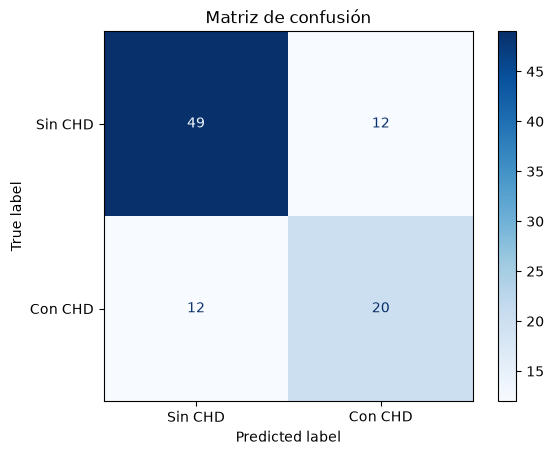

In [8]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Sin CHD", "Con CHD"], cmap="Blues"
)
plt.title("Matriz de confusión")
plt.show()

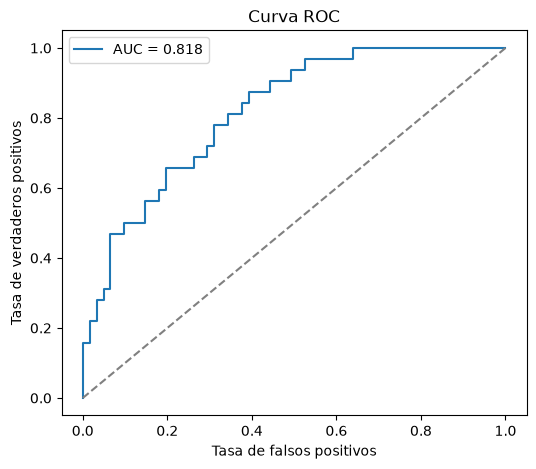

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC")
plt.legend()
plt.show()

## 8. Interpretación de los coeficientes

Con las variables escaladas, el signo y la magnitud de cada coeficiente indican dirección e importancia relativa. `exp(coeficiente)` se interpreta como el cambio en el *odds* (razón de probabilidades) de tener `chd` por cada desviación estándar de aumento en la variable.

El modelo entrenado vive dentro del pipeline, en `pipeline.named_steps["modelo"]`.

In [10]:
modelo_entrenado = pipeline.named_steps["modelo"]

coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": modelo_entrenado.coef_[0],
}).assign(odds_ratio=lambda d: np.exp(d["coeficiente"]))

coeficientes.sort_values("coeficiente", key=abs, ascending=False)

,variable,coeficiente,odds_ratio
8,Edad,0.716917,2.048110
4,Familia,0.436879,1.547869
2,ldl,0.394946,1.484304
5,Tipo,0.362494,1.436909
1,Tabaco,0.316602,1.372457
0,sbp,0.141051,1.151484
3,Adiposidad,-0.114875,0.891478
7,Alcohol,-0.046458,0.954605
6,Obesidad,-0.010854,0.989205


### Guía de Clase — Construcción del Bundle

**Predicción de Enfermedad Cardíaca — Parte 2 de 3** (entrenamiento → **bundle** → API)

Este notebook parte del modelo entrenado en `Entrenamiento_Modelo_Enfermedad_Cardiaca.ipynb` y construye, en vivo con el grupo, el artefacto que se podrá llevar a producción.

**Objetivo de la sesión:** que el grupo entienda *por qué* un bundle no es lo mismo que guardar el modelo, y salga con uno propio, verificado, al final de la clase.

## 0. Recapitulación rápida

Se reproduce el entrenamiento anterior en una sola celda, con los mismos parámetros (`random_state=42`), para que el grupo tenga todo en memoria sin depender de haber dejado el kernel anterior abierto.

## 1. ¿Por qué un bundle y no solo el modelo?

`pipeline` por sí solo, guardado con `joblib.dump(pipeline, "pipeline.pkl")`, ya resuelve el escalado automáticamente (esa es justamente la ventaja de haberlo entrenado como `Pipeline` en la sesión anterior). Pero todavía no alcanza para predecir en producción con seguridad: hace falta reproducir además otras cosas que el `Pipeline` no sabe por sí solo:

- **Orden de las columnas**: el `Pipeline` no sabe nombres de columnas, solo posiciones. Si en producción las variables llegan en otro orden, predice sobre datos que no son los que cree que son, sin lanzar ningún error.
- **Codificación de `Familia`**: si en producción alguien manda `"Present"` en inglés o `1`/`0` invertidos, la predicción queda mal sin que nada lo avise.
- **Versión de librerías**: un pipeline serializado con una versión de scikit-learn puede fallar o comportarse distinto al cargarse con otra.

**Pregunta para el grupo:** *¿qué pasaría si guardamos solo `pipeline` y, seis meses después, alguien más arma el request de la API mandando las columnas en otro orden?* — dejar que el grupo lo discuta antes de mostrar la solución.

## 2. Qué va dentro del bundle

Un diccionario con todo lo que la etapa de predicción necesita, además del pipeline:

| Clave | Contenido | Por qué |
|---|---|---|
| `pipeline` | el `Pipeline` entrenado (scaler + modelo, ya como una sola pieza) | escala y predice en un solo paso |
| `columnas` | lista ordenada de features | garantiza el mismo orden siempre |
| `mapeo_familia` | `{"Presente": 1, "Ausente": 0}` | la API debe poder codificar igual que aquí |
| `metadata` | versión de sklearn, fecha de entrenamiento | trazabilidad si algo falla en producción |

Comparado con la versión anterior (guardar `modelo` y `scaler` por separado), el bundle ahora tiene una pieza móvil menos de la que preocuparse.

In [11]:
import sklearn
from datetime import datetime

bundle = {
    "pipeline": pipeline,
    "columnas": list(X.columns),
    "mapeo_familia": {"Presente":1,"Ausente":0},
    "metadata": {
        "sklearn_version":sklearn.__version__,
        "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "Modelo": "LogisticRegression"
    }
}

bundle ["pipeline"]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['sbp','Tabaco','ldl',...,'Obesidad','Alcohol','Edad']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 3. Serialización con `joblib`

Se usa `joblib` en vez de `pickle` estándar: está optimizado para objetos que contienen arreglos de NumPy grandes (como los coeficientes de un modelo de scikit-learn), y es el estándar de facto para este tipo de artefactos.

In [12]:
import joblib
# Guardar bundle
joblib.dump(bundle, "modelo_bundle_e_cardiaca.pkl")

['modelo_bundle_e_cardiaca.pkl']

## 4. Verificación: cargar el bundle y predecir desde cero

Este es el paso que de verdad prueba si el bundle está completo: **cerrar los ojos y actuar como si fuéramos la API**. Se recibe un paciente como diccionario con sus valores originales (sin escalar, con `Familia` en texto), y la función debe devolver una predicción usando *solo* lo que está guardado en el bundle — nada de variables sueltas del notebook.

Nota para el grupo: ya no hace falta escalar a mano dentro de esta función — el `pipeline` lo hace solo, en el mismo `.predict()`.

In [13]:
def predecir_enfermedad(paciente: dict, bundle: dict)-> dict:

    fila = dict(paciente)
    fila["Familia"] = bundle["mapeo_familia"][fila["Familia"]]

    X_nuevo = pd.DataFrame([fila])[bundle["columnas"]]

    prediccion = bundle["pipeline"].predict(X_nuevo)[0]
    probabilidad = bundle["pipeline"].predict_proba(X_nuevo)[0,1]

    return{
        "chd_predicho": int(prediccion),
        "probabilidad":round(float(probabilidad),4)
    }


In [18]:
# Probar datos
bundle_cargado = joblib.load("modelo_bundle_e_cardiaca.pkl")

paciente_prueba = X_test.iloc[0].to_dict()

paciente_prueba["Familia"] = "Presente" if paciente_prueba["Familia"] == 1 else "Ausente"

resultado = predecir_enfermedad(paciente_prueba,bundle_cargado)

print("resultado via bundle", resultado)
print("Prediccion real y_test", y_test.iloc[0])
print("Probabilidad directa del pipelin original", pipeline.predict_proba(X_test.iloc[[0]])[0,1])

resultado via bundle {'chd_predicho': 0, 'probabilidad': 0.3548}
Prediccion real y_test 1
Probabilidad directa del pipelin original 0.3547863856681952


Si `resultado["probabilidad"]` coincide con la probabilidad calculada directamente desde `pipeline` (última línea de la celda anterior), el bundle está reproduciendo el flujo completo correctamente — encoding, orden de columnas y escalado incluidos.